In [1]:
import pandas as pd

In [9]:
df = pd.read_csv("real_estate_sales - Sheet1.csv")

In [10]:
df.head()

,months,project,city,units_available,units_sold,price_per_sqft,marketing_spend,leads,boking
0,jan,green heights,ahmedabad,100,10,5500,500000,200,8
1,feb,green heights,ahmedabad,90,12,5600,450000,180,9
2,mar,green heights,ahmedabad,78,15,5700,550000,250,12
3,jan,sky tower,surat,60,5,8000,300000,100,4
4,feb,sky tower,surat,55,7,8100,320000,110,5


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   months           6 non-null      object
 1   project          6 non-null      object
 2   city             6 non-null      object
 3   units_available  6 non-null      int64 
 4   units_sold       6 non-null      int64 
 5   price_per_sqft   6 non-null      int64 
 6   marketing_spend  6 non-null      int64 
 7   leads            6 non-null      int64 
 8   boking           6 non-null      int64 
dtypes: int64(6), object(3)
memory usage: 564.0+ bytes


In [13]:
df.describe()

,units_available,units_sold,price_per_sqft,marketing_spend,leads,boking
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,71.833333,9.500000,6850.000000,411666.666667,161.666667,7.333333
std,20.750100,3.619392,1372.224471,103037.210107,58.452260,2.943920
min,48.000000,5.000000,5500.000000,300000.000000,100.000000,4.000000
25%,56.250000,7.250000,5625.000000,327500.000000,115.000000,5.250000
50%,69.000000,9.000000,6850.000000,400000.000000,155.000000,7.000000
75%,87.000000,11.500000,8075.000000,487500.000000,195.000000,8.750000
max,100.000000,15.000000,8200.000000,550000.000000,250.000000,12.000000


In [14]:
df.isnull().sum()

months             0
project            0
city               0
units_available    0
units_sold         0
price_per_sqft     0
marketing_spend    0
leads              0
boking             0
dtype: int64

In [16]:
df.groupby("project")["units_sold"].sum()

project
green heights    37
sky tower        20
Name: units_sold, dtype: int64

In [17]:
df.groupby("city")["price_per_sqft"].mean()

city
ahmedabad    5600.0
surat        8100.0
Name: price_per_sqft, dtype: float64

In [20]:
df.groupby("project")["boking"].sum()

project
green heights    29
sky tower        15
Name: boking, dtype: int64

In [26]:
df["Conversion_Rate"] = (df["boking"] / df["leads"]) * 100

In [24]:
df["Inventory_Left"] = (df["units_available"] - df["units_sold"])

In [25]:
df.head()

,months,project,city,units_available,units_sold,price_per_sqft,marketing_spend,leads,boking,Conversion_Rate,Inventory_Left
0,jan,green heights,ahmedabad,100,10,5500,500000,200,8,4.000000,90
1,feb,green heights,ahmedabad,90,12,5600,450000,180,9,5.000000,78
2,mar,green heights,ahmedabad,78,15,5700,550000,250,12,4.800000,63
3,jan,sky tower,surat,60,5,8000,300000,100,4,4.000000,55
4,feb,sky tower,surat,55,7,8100,320000,110,5,4.545455,48


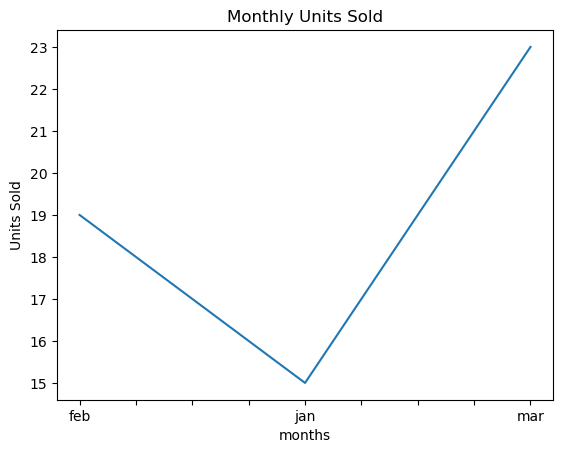

In [28]:
import matplotlib.pyplot as plt

monthly_sales = (df.groupby("months")["units_sold"].sum())

monthly_sales.plot(kind="line")

plt.title("Monthly Units Sold")
plt.ylabel("Units Sold")

plt.show()

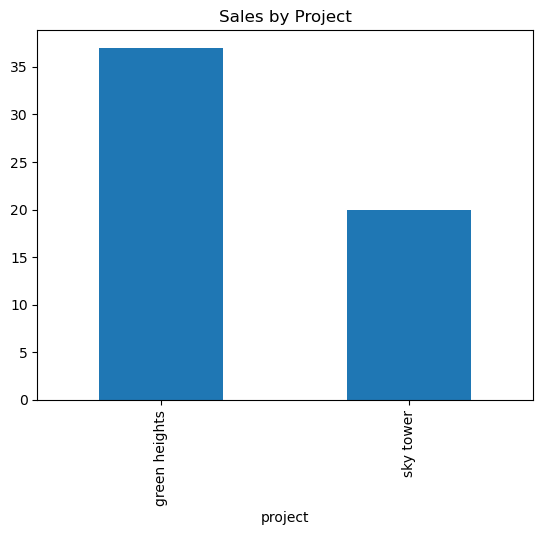

In [29]:
project_sales = (df.groupby("project")["units_sold"].sum())

project_sales.plot(kind="bar")

plt.title("Sales by Project")

plt.show()

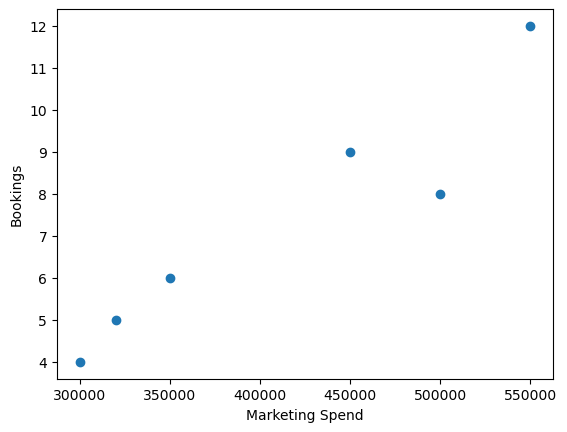

In [30]:
plt.scatter(df["marketing_spend"],df["boking"])

plt.xlabel("Marketing Spend")
plt.ylabel("Bookings")

plt.show()